# Задание: Сверточная нейронная сеть для распознавания рукописных цифр (MNIST) — PyTorch

**Параметры модели:** минимум 2 сверточных слоя; полносвязные слои; слои подвыборки, нормализации, регуляризации по 1 шт.

**Гиперпараметры обучения:** функция ошибки - категориальная кроссэнтропия, оптимизатор - Adam с шагом обучения одна тысячная, размер батча - 128, количество эпох 15, детали обучения - отображаются.

## Загрузка библиотек

In [1]:
# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Базовые библиотеки
import numpy as np
import matplotlib.pyplot as plt
import random

# Метрики
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Вывод изображений в ноутбуке
%matplotlib inline

# Определение устройства (GPU если доступен)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Используется устройство: {device}')

Используется устройство: cuda


## Загрузка датасета MNIST

In [2]:
# Преобразования: тензор + нормализация (среднее и std для MNIST)
# Здесь же выполняется приведение к диапазону [0, 1] (rescale)
transform = transforms.Compose([
    transforms.ToTensor(),                       # автоматически делит на 255 -> [0, 1]
    transforms.Normalize((0.1307,), (0.3081,))   # стандартная нормализация для MNIST
])

# Загрузка обучающей и проверочной выборок
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

print(f'Размер обучающей выборки: {len(train_dataset)}')
print(f'Размер тестовой выборки: {len(test_dataset)}')

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.62MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.1MB/s]

Размер обучающей выборки: 60000
Размер тестовой выборки: 10000


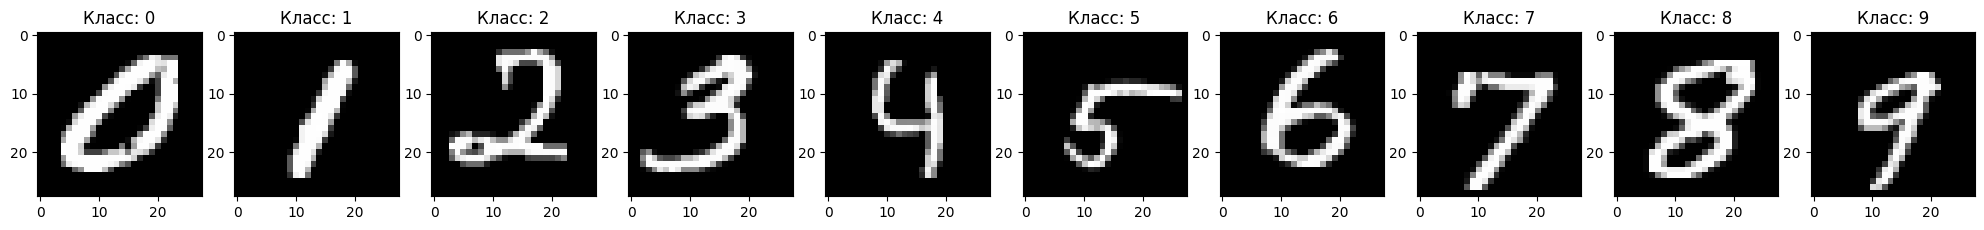

In [3]:
# Просмотр изображений каждого класса для ознакомления с датасетом
fig, axs = plt.subplots(1, 10, figsize=(25, 3))

# Получаем все метки
all_labels = train_dataset.targets.numpy()
all_images = train_dataset.data.numpy()

for i in range(10):
    label_indexes = np.where(all_labels == i)[0]
    index = random.choice(label_indexes)
    img = all_images[index]
    axs[i].imshow(img, cmap='gray')
    axs[i].set_title(f'Класс: {i}')

plt.show()

In [4]:
# Создание DataLoader-ов с размером батча 128
BATCH_SIZE = 128

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Проверка размерностей
for images, labels in train_loader:
    print(f'Форма батча изображений: {images.shape}')   # [128, 1, 28, 28]
    print(f'Форма батча меток:       {labels.shape}')   # [128]
    break

Форма батча изображений: torch.Size([128, 1, 28, 28])
Форма батча меток:       torch.Size([128])


## Создание модели CNN

В отличие от Keras, PyTorch требует явного определения класса модели. Описываем слои в `__init__` и порядок их применения в `forward`.

In [5]:
class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CNN, self).__init__()

        # ========== Первый сверточный блок ==========
        # Conv2D: 1 -> 32 канала, ядро 3x3, padding=1 (аналог padding='same')
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)               # Слой нормализации
        self.pool1 = nn.MaxPool2d(2, 2)             # Слой подвыборки 2x2 -> 14x14
        self.dropout1 = nn.Dropout2d(0.25)          # Слой регуляризации

        # ========== Второй сверточный блок ==========
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)             # 14x14 -> 7x7
        self.dropout2 = nn.Dropout2d(0.25)

        # ========== Полносвязная часть ==========
        # После двух пулингов: 64 канала * 7 * 7 = 3136 признаков
        self.fc1 = nn.Linear(64 * 7 * 7, 256)
        self.bn_fc = nn.BatchNorm1d(256)
        self.dropout_fc = nn.Dropout(0.5)

        # Выходной слой: 10 классов (без активации - CrossEntropyLoss применит softmax внутри)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        # Первый блок: Conv -> LeakyReLU -> BatchNorm -> Pool -> Dropout
        x = self.conv1(x)
        x = F.leaky_relu(x, negative_slope=0.1)
        x = self.bn1(x)
        x = self.pool1(x)
        x = self.dropout1(x)

        # Второй блок
        x = self.conv2(x)
        x = F.leaky_relu(x, negative_slope=0.1)
        x = self.bn2(x)
        x = self.pool2(x)
        x = self.dropout2(x)

        # Преобразование в вектор (аналог Flatten)
        x = x.view(x.size(0), -1)

        # Полносвязный блок
        x = self.fc1(x)
        x = F.leaky_relu(x, negative_slope=0.1)
        x = self.bn_fc(x)
        x = self.dropout_fc(x)

        # Выходной слой
        x = self.fc2(x)
        return x

# Создание модели и перенос на устройство
model = CNN(num_classes=10).to(device)
print(model)

# Подсчёт параметров
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nВсего параметров: {total_params:,}')
print(f'Обучаемых параметров: {trainable_params:,}')

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout2d(p=0.25, inplace=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout2): Dropout2d(p=0.25, inplace=False)
  (fc1): Linear(in_features=3136, out_features=256, bias=True)
  (bn_fc): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout_fc): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)

Всего параметров: 825,162
Обучаемых параметров: 825,162


## Обучение модели

In [6]:
# Функция потерь - категориальная кроссэнтропия
# В PyTorch CrossEntropyLoss совмещает softmax + nll_loss, поэтому метки передаются как индексы (не OHE)
criterion = nn.CrossEntropyLoss()

# Оптимизатор - Adam с шагом обучения 0.001
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 15

# Списки для хранения метрик
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [],   'val_acc': []
}

for epoch in range(EPOCHS):
    # ===== Фаза обучения =====
    model.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        # Обнуление градиентов
        optimizer.zero_grad()

        # Прямой проход
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Обратный проход и шаг оптимизатора
        loss.backward()
        optimizer.step()

        # Накопление метрик
        train_loss_sum += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

    train_loss = train_loss_sum / train_total
    train_acc = train_correct / train_total

    # ===== Фаза валидации =====
    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss_sum += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_loss = val_loss_sum / val_total
    val_acc = val_correct / val_total

    # Сохранение в историю
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Вывод деталей обучения
    print(f'Эпоха {epoch+1:2d}/{EPOCHS} | '
          f'train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f} | '
          f'val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f}')

print('\nОбучение завершено!')

Эпоха  1/15 | train_loss: 0.1530 | train_acc: 0.9545 | val_loss: 0.0460 | val_acc: 0.9853
Эпоха  2/15 | train_loss: 0.0695 | train_acc: 0.9782 | val_loss: 0.0303 | val_acc: 0.9900
Эпоха  3/15 | train_loss: 0.0546 | train_acc: 0.9829 | val_loss: 0.0292 | val_acc: 0.9904
Эпоха  4/15 | train_loss: 0.0476 | train_acc: 0.9845 | val_loss: 0.0254 | val_acc: 0.9918
Эпоха  5/15 | train_loss: 0.0397 | train_acc: 0.9877 | val_loss: 0.0238 | val_acc: 0.9922
Эпоха  6/15 | train_loss: 0.0353 | train_acc: 0.9892 | val_loss: 0.0255 | val_acc: 0.9917
Эпоха  7/15 | train_loss: 0.0337 | train_acc: 0.9893 | val_loss: 0.0222 | val_acc: 0.9922
Эпоха  8/15 | train_loss: 0.0307 | train_acc: 0.9905 | val_loss: 0.0257 | val_acc: 0.9911
Эпоха  9/15 | train_loss: 0.0293 | train_acc: 0.9904 | val_loss: 0.0233 | val_acc: 0.9924
Эпоха 10/15 | train_loss: 0.0282 | train_acc: 0.9907 | val_loss: 0.0208 | val_acc: 0.9937
Эпоха 11/15 | train_loss: 0.0234 | train_acc: 0.9922 | val_loss: 0.0216 | val_acc: 0.9927
Эпоха 12/1

## График обучения
Доли верных ответов на обучающей и проверочной выборках

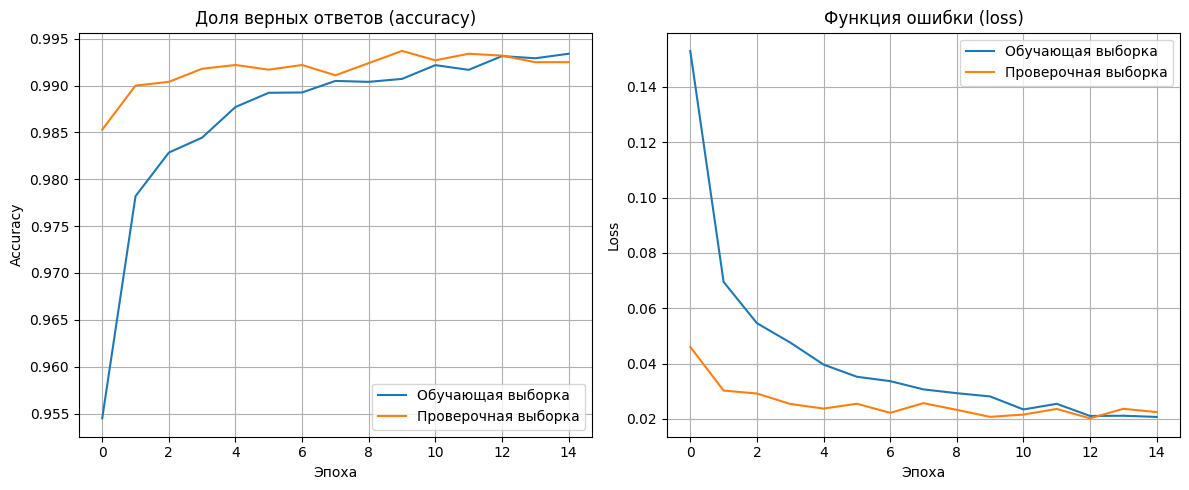

Лучшая точность на проверочной выборке: 0.9937 (99.37%)


In [7]:
plt.figure(figsize=(12, 5))

# График accuracy
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Обучающая выборка')
plt.plot(history['val_acc'], label='Проверочная выборка')
plt.title('Доля верных ответов (accuracy)')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# График loss
plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Обучающая выборка')
plt.plot(history['val_loss'], label='Проверочная выборка')
plt.title('Функция ошибки (loss)')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f'Лучшая точность на проверочной выборке: {max(history["val_acc"]):.4f} '
      f'({max(history["val_acc"])*100:.2f}%)')

## Матрица ошибок (Confusion Matrix)

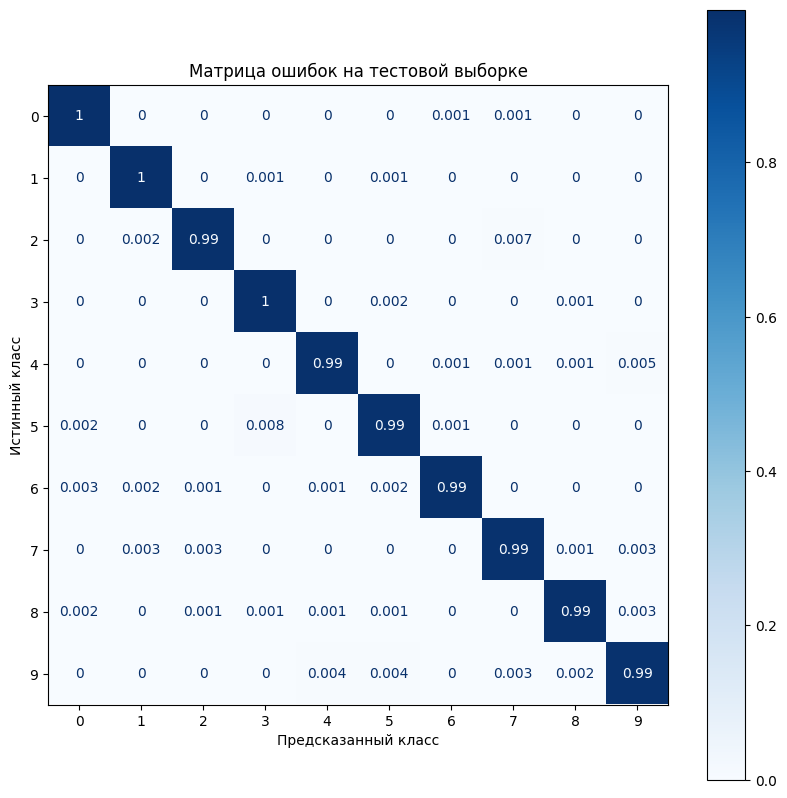


Общая точность на тестовой выборке: 0.9925 (99.25%)


In [8]:
# Получение всех предсказаний на тестовой выборке
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Построение нормализованной матрицы ошибок
cm = confusion_matrix(all_labels, all_preds, normalize='true')
cm = np.round(cm, 3)

fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
disp.plot(ax=ax, cmap='Blues', colorbar=True)
plt.title('Матрица ошибок на тестовой выборке')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

# Общая точность
accuracy = (all_preds == all_labels).mean()
print(f'\nОбщая точность на тестовой выборке: {accuracy:.4f} ({accuracy*100:.2f}%)')